````md id="hf7t2n"
# Introduction

This notebook is designed to help learn how to build **RNN** and **LSTM** networks for **time-dependent (sequential) data**.

While exploring how to build LSTM-based models for continuous time-series variables, I came across an excellent notebook (link). Much of the methodology and inspiration in this project is adapted from that work, and full credit goes to the original authors.

---

# Problem Statement

Predict whether an aircraft engine will fail within a specified number of future cycles using:

- Historical engine cycles  
- Sensor measurements  
- Operational settings  

In simple words:

> Given the engine's past behavior, can we warn early if failure is approaching?

---

# Why This Problem Matters

Aircraft engines are highly sensitive systems, and failures can have serious consequences.

Because of this, engines must be carefully monitored to ensure:

- Passenger safety  
- Reliable operation  
- Lower maintenance costs  
- Reduced unexpected downtime  

However, maintenance is also expensive.

So the challenge is:

- **Too little maintenance** → Risk of failure  
- **Too much maintenance** → Wasted cost and resources  

A smart predictive system helps schedule maintenance at the right time.

Aha! This is why predictive maintenance is so valuable.

---

# Notebook Contents

## 1. Importing Libraries

Load required Python libraries such as:

- NumPy  
- Pandas  
- Matplotlib  
- Scikit-learn  
- TensorFlow / Keras  

---

## 2. Load the Dataset

Load the aircraft engine dataset containing:

- Engine unit ID  
- Cycle number  
- Sensor readings  
- Operating conditions  

---

## 3. Data Preprocessing

Prepare the dataset for modeling.

### 3.1 Generate Classification Target Variable

Create labels such as:

```text id="m4aq9r"
1 = Engine likely to fail soon
0 = Engine operating normally
````

### 3.2 Normalize the Dataset

Scale numerical values so neural networks learn faster and better.

Why? Because large values and small values together can confuse training.

---

## 4. Exploratory Data Analysis (EDA)

Visualize:

* Sensor trends
* Failure patterns
* Correlations
* Engine degradation behavior

---

## 5. Generate Input Sequences

Convert raw rows into time windows.

Example:

```text id="0p6vld"
Last 50 cycles → Predict next failure risk
```

This allows RNN/LSTM models to learn patterns over time.

---

# 6. RNN Models

## 6.1 Simple RNN (1 Feature)

Train using a single sensor only.

## 6.2 Simple RNN (25 Features)

Train using multiple sensor inputs.

## 6.3 Bidirectional RNN (25 Features)

Learns both forward and backward sequence patterns.

---

# 7. Model Building with LSTM

Train LSTM networks that can remember long-term engine degradation signals.

Why? Because standard RNNs often forget older information.

LSTM solves that using memory gates.

---

# Final Goal

Compare all models and determine which architecture best predicts engine failure early.

```
```


In [67]:
from tensorflow import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, recall_score, precision_score
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM

In [123]:
sns.set_style('whitegrid')
colors = ['black', 'red']

In [69]:
# We will set the seed for reproducibility.
np.random.seed(1234)  
PYTHONHASHSEED = 0

In [70]:
path_test = '/Users/youssefaittizi/Desktop/Benchmark Code/PHM/Data/Data/PM_test.txt'
path_train = '/Users/youssefaittizi/Desktop/Benchmark Code/PHM/Data/Data/PM_train.txt'
path_truth = '/Users/youssefaittizi/Desktop/Benchmark Code/PHM/Data/Data/PM_truth.txt'

# Training data where the last cycle is the failure point for the engines
train_df = pd.read_csv(path_train, sep=" ", header=None)

# Test data where the failure point is not given for the engines
test_df = pd.read_csv(path_test, sep=" ", header=None)

# We wil print some rows of the train data
train_df.head(100)

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1,96,-0.0034,0.0001,100.0,518.67,642.19,1584.07,1395.16,14.62,...,8130.69,8.4311,0.03,392,2388,100.0,38.88,23.3255,NaN,NaN
96,1,97,0.0035,-0.0003,100.0,518.67,642.07,1595.77,1407.81,14.62,...,8128.74,8.4105,0.03,392,2388,100.0,39.01,23.2963,NaN,NaN
97,1,98,0.0006,0.0004,100.0,518.67,642.00,1591.11,1404.56,14.62,...,8127.89,8.4012,0.03,391,2388,100.0,38.96,23.2554,NaN,NaN
98,1,99,-0.0005,-0.0000,100.0,518.67,642.46,1592.73,1406.13,14.62,...,8131.77,8.4481,0.03,393,2388,100.0,38.82,23.2323,NaN,NaN


In [71]:
# Let's drop the NAN columns 26 and 27 using the dropna() method.
train_df.dropna(axis=1, inplace=True)
test_df.dropna(axis=1, inplace=True)

In [72]:
print(len(train_df))
print(len(test_df))

20631
13096


In [73]:
cols_names = ['id', 'cycle', 'setting1', 'setting2', 'setting3', 's1', 's2', 's3',
                     's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14',
                     's15', 's16', 's17', 's18', 's19', 's20', 's21']

train_df.columns = cols_names
test_df.columns = cols_names

train_df.head(2)

,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236


In [74]:
test_df.head(2)

,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916


In [75]:
# Load the ground truth for the test data, which indicates the remaining useful cycles for the engines

truth_df = pd.read_csv(path_truth, sep=" ", header=None)
truth_df.head()

,0,1
0,112,NaN
1,98,NaN
2,69,NaN
3,82,NaN
4,91,NaN


In [76]:
# We wil drop the NAN column
truth_df.dropna(axis=1, inplace=True)
truth_df.head()

,0
0,112
1,98
2,69
3,82
4,91


In [77]:
# method and specify which columns are to be considered while sorting using the parameter.

train_df.sort_values(['id','cycle'], inplace=True)
test_df.sort_values(['id','cycle'], inplace=True)

In [78]:
# Extract the maximum number of cycles for each engine id.
rul = pd.DataFrame(train_df.groupby('id')['cycle'].max()).reset_index()

# Name the columns and merge them with the training data.
rul.columns = ['id', 'max']
train_df = train_df.merge(rul, on=['id'], how='left')

# Now subtract the current cycle from the max (maximum number of cycles) to calculate the remaining useful life.
train_df['RUL'] = train_df['max'] - train_df['cycle']

#The RUL is calculated for each id.
train_df[['id','cycle','max','RUL']].head()

,id,cycle,max,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187


In [79]:
# We do not need "max" anymore.
train_df.drop('max', axis=1, inplace=True)

In [80]:
# We will make a label that indicates whether an engine is going to fail within w1 cycles.
w1 = 30
train_df['failure_within_w1'] = np.where(train_df['RUL'] <= w1, 1, 0 )

In [81]:
# Make a separate feature for the normalized value of the cycle column.
train_df['cycle_norm'] = train_df['cycle']

# Using the difference function, we exclude these columns from the normalization process.
cols_normalize = train_df.columns.difference(['id','cycle','RUL','failure_within_w1'])

# MinMax normalization (from 0 to 1) of sensor data
min_max_scaler = preprocessing.MinMaxScaler()
norm_train_df = pd.DataFrame(min_max_scaler.fit_transform(train_df[cols_normalize]), 
                             columns=cols_normalize, 
                             index=train_df.index)

#Join the normalized and non-normalized data.
join_df = train_df[['id','cycle','RUL','failure_within_w1']].join(norm_train_df)
train_df = join_df.reindex(columns = train_df.columns)

train_df.head()

,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s15,s16,s17,s18,s19,s20,s21,RUL,failure_within_w1,cycle_norm
0,1,1,0.459770,0.166667,0.0,0.0,0.183735,0.406802,0.309757,0.0,...,0.363986,0.0,0.333333,0.0,0.0,0.713178,0.724662,191,0,0.00000
1,1,2,0.609195,0.250000,0.0,0.0,0.283133,0.453019,0.352633,0.0,...,0.411312,0.0,0.333333,0.0,0.0,0.666667,0.731014,190,0,0.00277
2,1,3,0.252874,0.750000,0.0,0.0,0.343373,0.369523,0.370527,0.0,...,0.357445,0.0,0.166667,0.0,0.0,0.627907,0.621375,189,0,0.00554
3,1,4,0.540230,0.500000,0.0,0.0,0.343373,0.256159,0.331195,0.0,...,0.166603,0.0,0.333333,0.0,0.0,0.573643,0.662386,188,0,0.00831
4,1,5,0.390805,0.333333,0.0,0.0,0.349398,0.257467,0.404625,0.0,...,0.402078,0.0,0.416667,0.0,0.0,0.589147,0.704502,187,0,0.01108


Normalize the test data in the same manner that you normalized the training data.

In [82]:
# We will perform MinMax normalization (from 0 to 1)
test_df['cycle_norm'] = test_df['cycle']

# MinMax normalization (from 0 to 1) of the sensor data only
norm_test_df = pd.DataFrame(min_max_scaler.transform(test_df[cols_normalize]), 
                            columns=cols_normalize, 
                            index=test_df.index)

#Join the normalized and non-normalized data (it does not have 'RUL' and 'failure_within_w1')
test_join_df = test_df[test_df.columns.difference(cols_normalize)].join(norm_test_df)
test_df = test_join_df.reindex(columns = test_df.columns)
test_df = test_df.reset_index(drop=True)

In [83]:
# Let's calculate the total RUL by summing up the maximum cycles given in the test set and the 
# ground truth additional RUL.
rul = pd.DataFrame(test_df.groupby('id')['cycle'].max()).reset_index()
rul.columns = ['id', 'max']
truth_df.columns = ['additional_rul']

# The respective id can be obtained by adding 1 to the index, as the index starts from 0.
truth_df['id'] = truth_df.index + 1

# Add the max cycles given in the test set and the additional RUL given in the ground truth DataFrame.
truth_df['max'] = rul['max'] + truth_df['additional_rul']
truth_df.drop('additional_rul', axis=1, inplace=True)

# Generate the RUL for the test data.
test_df = test_df.merge(truth_df, on=['id'], how='left')
test_df['RUL'] = test_df['max'] - test_df['cycle']
test_df.drop('max', axis=1, inplace=True)

# Generate the label columns w0 and w1 for the test data.
test_df['failure_within_w1'] = np.where(test_df['RUL'] <= w1, 1, 0 )
test_df.head()

,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s15,s16,s17,s18,s19,s20,s21,cycle_norm,RUL,failure_within_w1
0,1,1,0.632184,0.750000,0.0,0.0,0.545181,0.310661,0.269413,0.0,...,0.308965,0.0,0.333333,0.0,0.0,0.558140,0.661834,0.00000,142,0
1,1,2,0.344828,0.250000,0.0,0.0,0.150602,0.379551,0.222316,0.0,...,0.213159,0.0,0.416667,0.0,0.0,0.682171,0.686827,0.00277,141,0
2,1,3,0.517241,0.583333,0.0,0.0,0.376506,0.346632,0.322248,0.0,...,0.458638,0.0,0.416667,0.0,0.0,0.728682,0.721348,0.00554,140,0
3,1,4,0.741379,0.500000,0.0,0.0,0.370482,0.285154,0.408001,0.0,...,0.257022,0.0,0.250000,0.0,0.0,0.666667,0.662110,0.00831,139,0
4,1,5,0.580460,0.500000,0.0,0.0,0.391566,0.352082,0.332039,0.0,...,0.300885,0.0,0.166667,0.0,0.0,0.658915,0.716377,0.01108,138,0


4. Exploratory Data Analysis - EDA
Let's see how the sensor values change for a particular engine id, say id=1.

<Axes: >

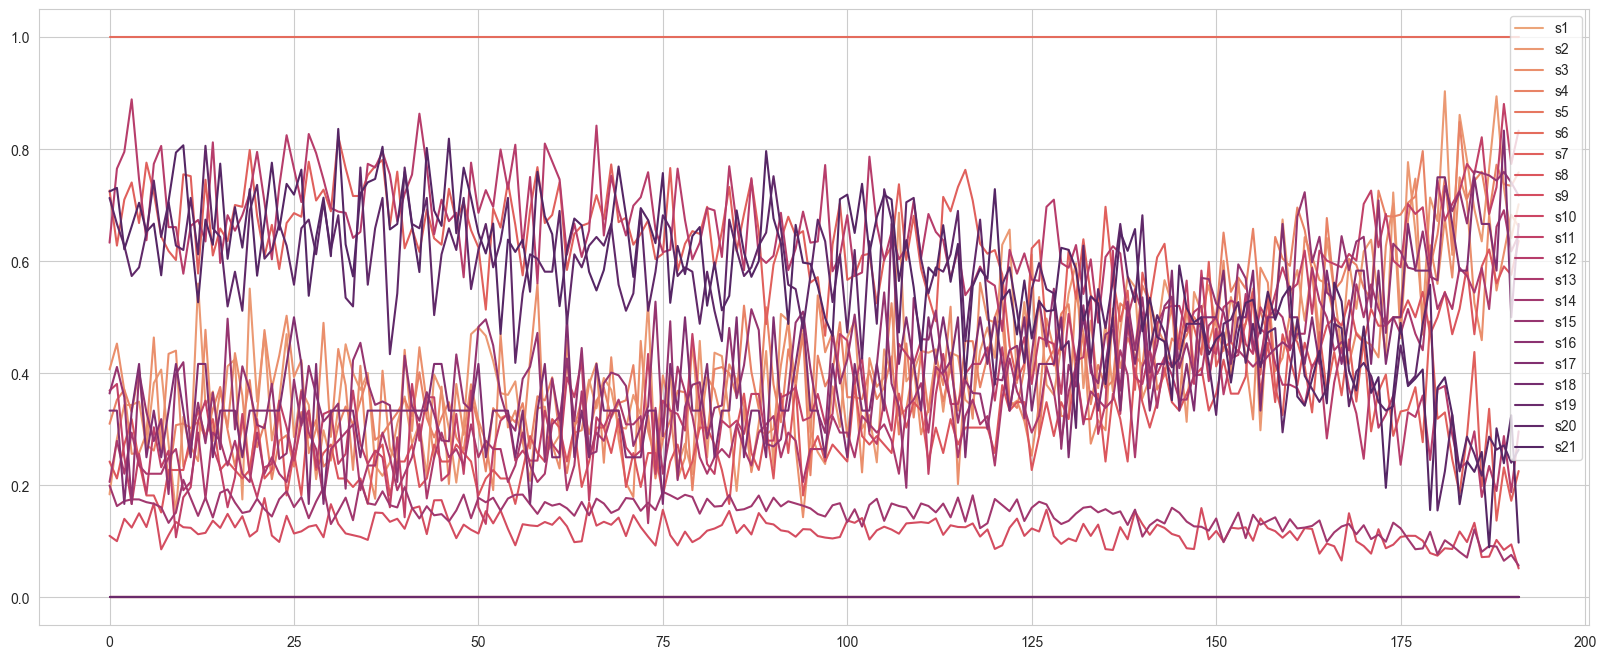

In [ ]:
palette = sns.color_palette("flare", n_colors=21)
sensor_cols = cols_names[5:]
train_df[train_df.id==1][sensor_cols].plot(figsize=(20, 8), color=palette, lege)

<Axes: title={'center': 'Sensor 2 for engine 1'}>

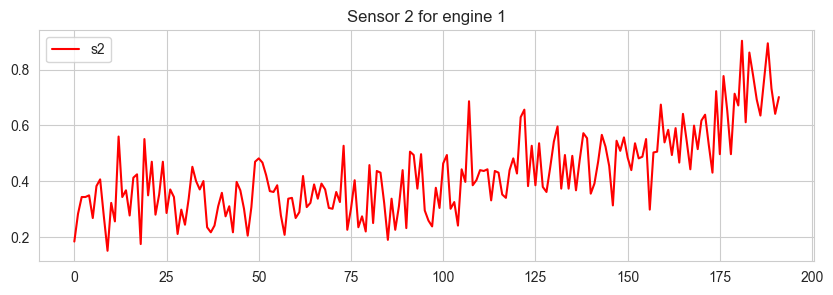

In [ ]:
train_df[train_df.id==1][sensor_cols[1]].plot(figsize=(10, 3), title='Sensor 2 for engine 1', color=colors[1], legend=True)


<Axes: title={'center': 'Sensor 2 for engine 5'}>

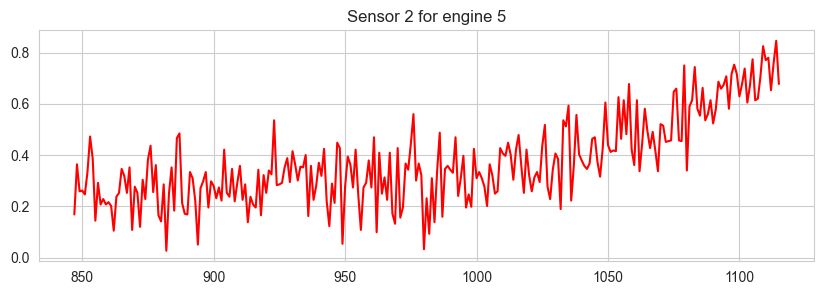

In [125]:
train_df[train_df.id==5][sensor_cols[1]].plot(figsize=(10, 3), title='Sensor 2 for engine 5', color=colors[1])


<Axes: title={'center': 'Sensor 7 for engine 1'}>

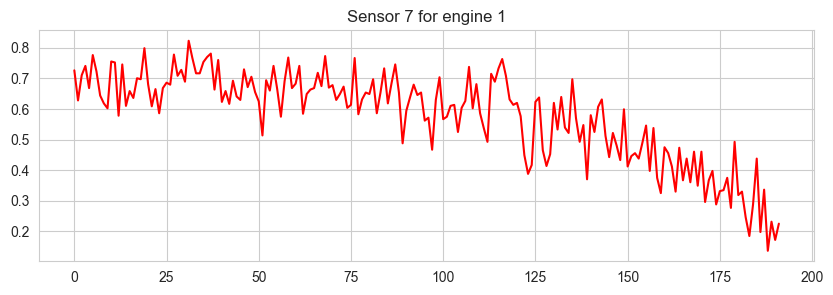

In [127]:
train_df[train_df.id==1][sensor_cols[6]].plot(figsize=(10, 3), title='Sensor 7 for engine 1', color=colors[1])


<Axes: title={'center': 'Sensor 7 for engine 50'}>

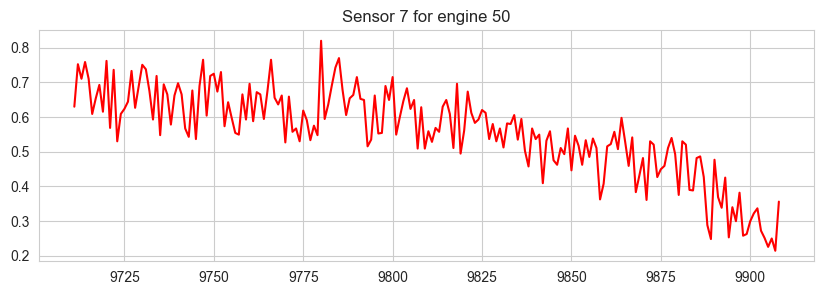

In [128]:
train_df[train_df.id==50][sensor_cols[6]].plot(figsize=(10, 3), title='Sensor 7 for engine 50', color=colors[1])


In [89]:
# The sequence length to be used for predictions is as follows:
sequence_length = 50

# The function to generate sequences (samples, time steps, features) for a particular engine id is as follows:

def sequence_generator(feature_df, seq_length, seq_cols):
    # We will not be using any sequence below seq_length.
    # Convert the DataFrame into a NumPy 2D array.
    feature_array = feature_df[seq_cols].values
    num_elements = feature_array.shape[0]

    # We want to generate sequences of 50 timesteps at a time.
    # Hence, we will iterate over two sets of indices: (0,142),(50,192).
    # For example, id1 has 192 rows, and its sequence_length is equal to 50.
    # 0 50 -> From row 0 to row 50
    # 1 51 -> From row 1 to row 51
    # 2 52 -> From row 2 to row 52
    # ...
    # 141 191 -> From row 111 to 191
    
    for start, stop in zip(range(0, num_elements-seq_length), range(seq_length, num_elements)):
        yield feature_array[start:stop, :]

In [90]:
# Generate sequences for each engine id.
# unique() returns all the unique ids in a list.

seq_gen = (list(sequence_generator(train_df[train_df['id']==id], sequence_length, ["s2"])) # We take only one feature (s2).
           for id in train_df['id'].unique())

# Concatenate the sequences of different engine ids into one array and convert that into a NumPy array 
# [(142, 50, 25), ...] --> [(ntotal, 50, 25)].
#print(list(seq_gen))
seq_set = np.concatenate(list(seq_gen)).astype(np.float32)

# Let’s print the shape of the seq_set  (number of samples, number of time steps, number of features)
seq_set.shape

(15631, 50, 1)

In [91]:
# The function to generate labels is as follows:
def label_generator(label_df, seq_length, label):
    # Funtion will return
    # This function will return the following:
    # [[1]
    # [4]
    # [1]
    # [5]
    # [9]
    # ...
    # [200]]
    # Convert the labels into a NumPy 2D array. 

    label_array = label_df[label].values
    num_elements = label_array.shape[0]
        # Remove the first label, as the first prediction will be the (seq_length+1)th label. 
    return label_array[seq_length:num_elements, :]

In [92]:
# Generate labels [[142,1], [121, 1], [3]] --> [1, 2, 3] (ntotal, 1).
label_gen = [label_generator(train_df[train_df['id']==id], sequence_length, ['failure_within_w1']) 
             for id in train_df['id'].unique()]
label_set = np.concatenate(label_gen).astype(np.float32)
label_set.shape

(15631, 1)

6. RNN Models

We will build, train, and evaluate the following models:

Simple RNN [1 Feature]
Simple RNN [25 Features]
Bi-Directional RNN [25 Features]

In [93]:
out_dim = label_set.shape[1] # 1 label/output for one sequence.
features_dim = seq_set.shape[2] # Number of features (1)


print("Features dimension: ", features_dim)
print("Output dimension: ", out_dim)

RNN_fwd = Sequential()

# Add the RNN unit.
# Understand the parameters.
RNN_fwd.add(SimpleRNN(
         input_shape=(sequence_length, features_dim),
         units=1,
         return_sequences=False))
RNN_fwd.add(Dropout(0.2))

RNN_fwd.add(Dense(units=out_dim, activation='sigmoid'))

# Compile the model.
RNN_fwd.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print(RNN_fwd.summary())

# Define the path to save the model.
RNN_fwd_path = '/Users/youssefaittizi/Desktop/Benchmark Code/PHM/Data/Models/RNN_fwd.h5'

Features dimension:  1
Output dimension:  1


/Users/youssefaittizi/Desktop/Benchmark Code/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (20.00 B)

 Trainable params: 5 (20.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [94]:
import time
epochs = 300
batch_size = 200
start = time.time()

# Fit the network.
RNN_fwd_history = RNN_fwd.fit(seq_set, label_set, epochs=epochs, batch_size=batch_size, validation_split=0.05, verbose=2, 
                              callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=0, mode='min'),
                       keras.callbacks.ModelCheckpoint(RNN_fwd_path,monitor='val_loss', save_best_only=True, mode='min', verbose=0)]
          )
end = time.time()
print("Total time taken for training: ", "{:.2f}".format((end-start)), " secs")

Epoch 1/300


75/75 - 1s - 10ms/step - accuracy: 0.5464 - loss: 0.7313 - val_accuracy: 0.5959 - val_loss: 0.6878
Epoch 2/300


75/75 - 0s - 2ms/step - accuracy: 0.6860 - loss: 0.6456 - val_accuracy: 0.6611 - val_loss: 0.6255
Epoch 3/300


75/75 - 0s - 2ms/step - accuracy: 0.7378 - loss: 0.5890 - val_accuracy: 0.7174 - val_loss: 0.5744
Epoch 4/300


75/75 - 0s - 3ms/step - accuracy: 0.7636 - loss: 0.5560 - val_accuracy: 0.7455 - val_loss: 0.5452
Epoch 5/300


...

75/75 - 0s - 2ms/step - accuracy: 0.8599 - loss: 0.3366 - val_accuracy: 0.8772 - val_loss: 0.2836
Epoch 122/300
75/75 - 0s - 2ms/step - accuracy: 0.8592 - loss: 0.3348 - val_accuracy: 0.8734 - val_loss: 0.2848
Epoch 123/300


75/75 - 0s - 3ms/step - accuracy: 0.8594 - loss: 0.3347 - val_accuracy: 0.8772 - val_loss: 0.2827
Epoch 124/300


75/75 - 0s - 2ms/step - accuracy: 0.8595 - loss: 0.3332 - val_accuracy: 0.8785 - val_loss: 0.2811
Epoch 125/300
75/75 - 0s - 2ms/step - accuracy: 0.8580 - loss: 0.3377 - val_accuracy: 0.8772 - val_loss: 0.2821
Epoch 126/300


75/75 - 0s - 2ms/step - accuracy: 0.8603 - loss: 0.3342 - val_accuracy: 0.8785 - val_loss: 0.2804
Epoch 127/300
75/75 - 0s - 2ms/step - accuracy: 0.8597 - loss: 0.3349 - val_accuracy: 0.8760 - val_loss: 0.2829
Epoch 128/300


75/75 - 0s - 2ms/step - accuracy: 0.8611 - loss: 0.3361 - val_accuracy: 0.8824 - val_loss: 0.2748
Epoch 129/300
75/75 - 0s - 2ms/step - accuracy: 0.8607 - loss: 0.3370 - val_accuracy: 0.8772 - val_loss: 0.2804
Epoch 130/300
75/75 - 0s - 2ms/step - accuracy: 0.8596 - loss: 0.3334 - val_accuracy: 0.8785 - val_loss: 0.2794
Epoch 131/300
75/75 - 0s - 2ms/step - accuracy: 0.8609 - loss: 0.3337 - val_accuracy: 0.8785 - val_loss: 0.2785
Epoch 132/300
75/75 - 0s - 2ms/step - accuracy: 0.8594 - loss: 0.3355 - val_accuracy: 0.8760 - val_loss: 0.2799
Epoch 133/300
75/75 - 0s - 2ms/step - accuracy: 0.8600 - loss: 0.3379 - val_accuracy: 0.8798 - val_loss: 0.2777
Epoch 134/300
75/75 - 0s - 2ms/step - accuracy: 0.8618 - loss: 0.3305 - val_accuracy: 0.8785 - val_loss: 0.2780
Epoch 135/300
75/75 - 0s - 2ms/step - accuracy: 0.8602 - loss: 0.3347 - val_accuracy: 0.8772 - val_loss: 0.2786
Epoch 136/300
75/75 - 0s - 2ms/step - accuracy: 0.8620 - loss: 0.3319 - val_accuracy: 0.8772 - val_loss: 0.2781
Epoch 

In [129]:

# The function for plotting the change in the model’s accuracy on the train and validation sets is as follows:
def plot_model_accuracy(model_name_history, width = 10, height = 10):

  fig_acc = plt.figure(figsize=(width, height))
  plt.plot(model_name_history.history['accuracy'], color=colors[0])
  plt.plot(model_name_history.history['val_accuracy'], color=colors[1])
  plt.title('model accuracy')
  plt.ylabel('accuracy')
  plt.xlabel('epoch')
  plt.legend(['train', 'val'], loc='upper left')
  plt.show()

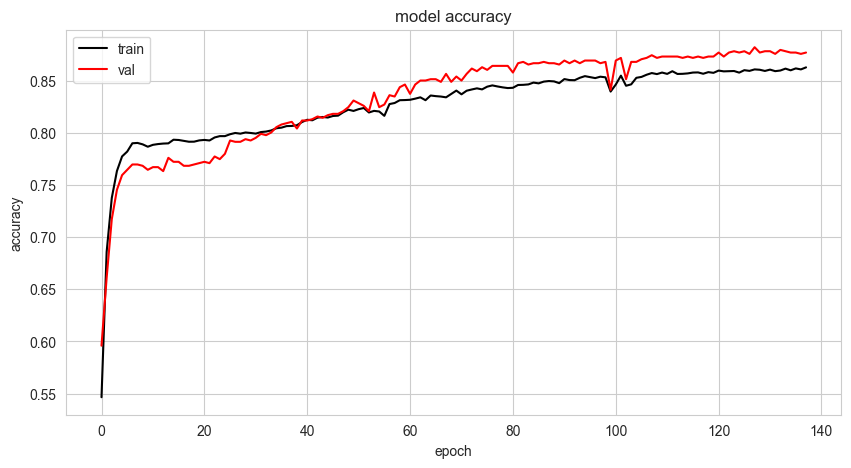

In [130]:
#Call the function.
plot_model_accuracy(RNN_fwd_history,10,5)

In [131]:
# We will define a function to plot the change in the loss on the train and validation sets.
def plot_training_curve(model_name_history, width = 10, height = 10):
  fig_acc = plt.figure(figsize=(width, height))
  plt.plot(model_name_history.history['loss'], color=colors[0])
  plt.plot(model_name_history.history['val_loss'], color=colors[1])
  plt.title('model loss')
  plt.ylabel('loss')
  plt.xlabel('epoch')
  plt.legend(['train', 'val'], loc='upper left')
  plt.show()

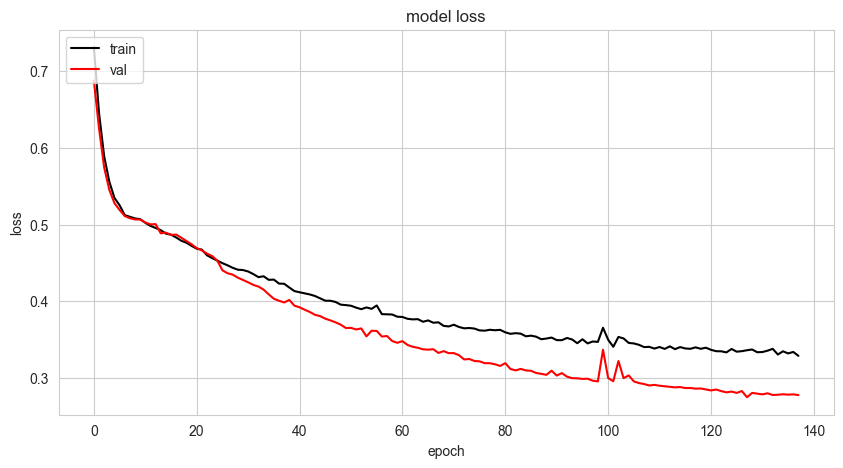

In [132]:
#Call the function.
plot_training_curve(RNN_fwd_history,10,5)

In [99]:
def analyze_model_on_train_set(input_sequence_set, model_name):

  # The training metrics are as follows:
  model_history_scores = model_name.evaluate(input_sequence_set, label_set, verbose=1, batch_size=50)
  print('Train Accurracy: {}'.format(model_history_scores[1]))

  # Make predictions and compute the confusion matrix.
  y_pred = (model_name.predict(input_sequence_set, verbose=1, batch_size=200) > 0.5).astype("int32")
  y_true = label_set

  test_set = pd.DataFrame(y_pred)
  test_set.to_csv('binary_submit_train.csv', index = None)

  print('Confusion matrix\n- x-axis is true labels.\n- y-axis is predicted labels')
  model_cm = confusion_matrix(y_true, y_pred)
  print(model_cm)

  # Compute the precision and recall.
  model_precision = precision_score(y_true, y_pred)
  model_recall = recall_score(y_true, y_pred)
  print( 'Train Precision = ', model_precision, '\n', 'Train Recall = ', model_recall)

# Call the function.
analyze_model_on_train_set(seq_set, RNN_fwd)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 665us/step - accuracy: 0.8702 - loss: 0.2978
Train Accurracy: 0.8701938390731812


79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Confusion matrix
- x-axis is true labels.
- y-axis is predicted labels
[[12229   302]
 [ 1727  1373]]
Train Precision =  0.8197014925373134 
 Train Recall =  0.44290322580645164


In [135]:
def analyze_model_on_test_set(input_sequence_columns, model_path, width= 10, height=5):
  # We will consider all the last sequences of the test set.
  last_test_seq = [test_df[test_df['id']==id][input_sequence_columns].values[-sequence_length:] 
                        for id in test_df['id'].unique() if len(test_df[test_df['id']==id]) >= sequence_length]
  last_test_seq = np.asarray(last_test_seq).astype(np.float32)
  
  # Get the labels of the test set.
  y_mask = [len(test_df[test_df['id']==id]) >= sequence_length for id in test_df['id'].unique()]
  last_test_label = test_df.groupby('id')['failure_within_w1'].nth(-1)[y_mask].values
  last_test_label = last_test_label.reshape(last_test_label.shape[0],1).astype(np.float32)

  # If the best model weights were saved, load them.
  if os.path.isfile(model_path):
    print("using " + model_path)
    model_estimator = load_model(model_path)

  # Test the metrics.
  start = time.time()
  scores_test = model_estimator.evaluate(last_test_seq, last_test_label, verbose=2)
  end = time.time()
  print("Total time taken for inferencing: ", "{:.2f}".format((end-start)), " secs")

  print('Test Accurracy: {}'.format(scores_test[1]))

  # Make predictions and compute the confusion matrix.
  y_model_estimator_pred_test = (model_estimator.predict(last_test_seq) >0.5).astype("int32")
  y_true_test = last_test_label

  test_set = pd.DataFrame(y_model_estimator_pred_test)
  test_set.to_csv('binary_submit_test.csv', index = None)

  print('Confusion matrix\n- x-axis is true labels.\n- y-axis is predicted labels')
  model_estimator_conf_m = confusion_matrix(y_true_test, y_model_estimator_pred_test)
  print(model_estimator_conf_m)

  # Compute the precision and recall values.
  model_estimator_precision_test = precision_score(y_true_test, y_model_estimator_pred_test)
  model_estimator_recall_test = recall_score(y_true_test, y_model_estimator_pred_test)
  f1_test = 2 * (model_estimator_precision_test * model_estimator_recall_test) / (model_estimator_precision_test + model_estimator_recall_test)
  print( 'Test Precision: ', model_estimator_precision_test, '\n', 'Test Recall: ', model_estimator_recall_test,'\n', 'Test F1-score:', f1_test )

  # Plot the predicted data in blue and the
  # actual data in green to visually verify the accuracy of the model.
  fig_verify = plt.figure(figsize=(10, 5))
  plt.plot(y_model_estimator_pred_test, color=colors[1])
  plt.plot(y_true_test, color=colors[0])
  plt.title('prediction')
  plt.ylabel('value')
  plt.xlabel('row')
  plt.legend(['predicted', 'actual data'], loc='upper left')
  plt.show()

using /Users/youssefaittizi/Desktop/Benchmark Code/PHM/Data/Models/RNN_fwd.h5
3/3 - 0s - 56ms/step - accuracy: 0.8172 - loss: 0.3637
Total time taken for inferencing:  0.19  secs
Test Accurracy: 0.8172042965888977
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Confusion matrix
- x-axis is true labels.
- y-axis is predicted labels
[[66  2]
 [15 10]]
Test Precision:  0.8333333333333334 
 Test Recall:  0.4 
 Test F1-score: 0.5405405405405406


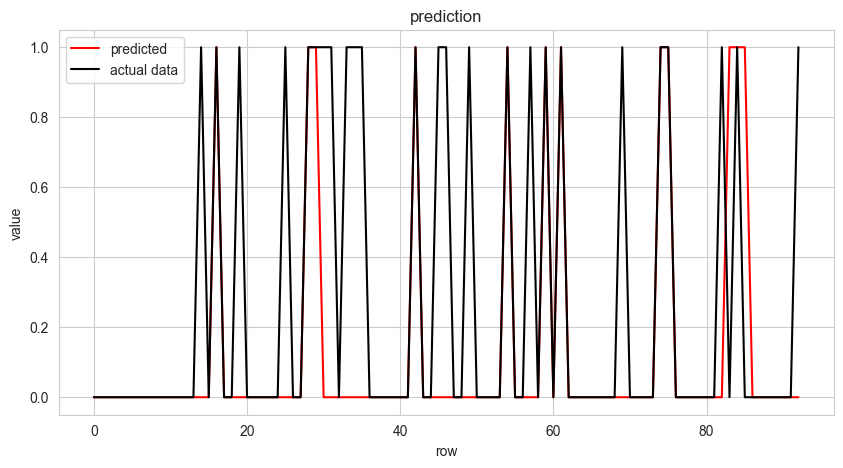

In [136]:
#Call the function.
analyze_model_on_test_set(["s2"], RNN_fwd_path, 10, 5)

In [102]:
# Pick the feature columns. 
sensor_cols = ['s' + str(i) for i in range(1,22)]
sequence_cols_25 = ['setting1', 'setting2', 'setting3', 'cycle_norm']
sequence_cols_25.extend(sensor_cols) # Add the elements of sensor_cols into sequence_cols.

In [103]:
# Generate sequences for each engine id.
# unique() returns all the unique ids in a list.

seq_gen = (list(sequence_generator(train_df[train_df['id']==id], sequence_length, sequence_cols_25)) #We will take all the features (25).
           for id in train_df['id'].unique())

# Concatenate the sequences of the different engine ids into one and convert it into a NumPy array [(142, 50, 25), ...] --> [(ntotal, 50, 25)].
seq_set_f25 = np.concatenate(list(seq_gen)).astype(np.float32)

#The shape denotes (number of samples, number of time steps, number of features).
seq_set_f25.shape

(15631, 50, 25)

In [104]:
features_dim = seq_set_f25.shape[2] # number of features (25).
out_dim = label_set.shape[1] # One label (failure_within_w1).

print("Features dimension: ", features_dim)
print("Output dimension: ", out_dim)

RNN_fwd_2 = Sequential()

# Understanding return_sequences and the connection across RNN layers:
# We have to return the sequences from the first layer so the next layer can get the sequence.

RNN_fwd_2.add(SimpleRNN(
         input_shape=(sequence_length, features_dim),
         units=5,
         return_sequences=True))
RNN_fwd_2.add(Dropout(0.2))

RNN_fwd_2.add(SimpleRNN(
          units=3,
          return_sequences=False))
RNN_fwd_2.add(Dropout(0.2))

RNN_fwd_2.add(Dense(units=out_dim, activation='sigmoid'))

# Compile the model.
RNN_fwd_2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print(RNN_fwd_2.summary())

# Define the path to save the model.
RNN_fwd_2_path = '/Users/youssefaittizi/Desktop/Benchmark Code/PHM/Data/Models/RNN_fwd_2.h5'

Features dimension:  25
Output dimension:  1


/Users/youssefaittizi/Desktop/Benchmark Code/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 50, 5)          │           155 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 3)              │            27 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186 (744.00 B)

 Trainable params: 186 (744.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [105]:
import time
epochs = 200
batch_size = 200
start = time.time()

# Fit the network.
RNN_fwd_2_history = RNN_fwd_2.fit(seq_set_f25, label_set, epochs=epochs, batch_size=batch_size, validation_split=0.05, verbose=2,
          callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=0, mode='min'),
                       keras.callbacks.ModelCheckpoint(RNN_fwd_2_path,monitor='val_loss', save_best_only=True, mode='min', verbose=0)]
          )
end = time.time()
print("Total time taken for training: ", "{:.2f}".format((end-start)), " secs")

Epoch 1/200


75/75 - 2s - 20ms/step - accuracy: 0.7436 - loss: 0.5594 - val_accuracy: 0.8018 - val_loss: 0.4970
Epoch 2/200


75/75 - 0s - 6ms/step - accuracy: 0.7811 - loss: 0.5240 - val_accuracy: 0.8018 - val_loss: 0.4622
Epoch 3/200


75/75 - 0s - 5ms/step - accuracy: 0.8753 - loss: 0.3639 - val_accuracy: 0.9182 - val_loss: 0.2758
Epoch 4/200


75/75 - 0s - 5ms/step - accuracy: 0.9101 - loss: 0.2830 - val_accuracy: 0.9169 - val_loss: 0.2558
Epoch 5/200


...

75/75 - 0s - 5ms/step - accuracy: 0.9446 - loss: 0.1447 - val_accuracy: 0.9565 - val_loss: 0.1122
Epoch 38/200
75/75 - 0s - 5ms/step - accuracy: 0.9465 - loss: 0.1434 - val_accuracy: 0.9514 - val_loss: 0.1249
Epoch 39/200
75/75 - 0s - 5ms/step - accuracy: 0.9451 - loss: 0.1466 - val_accuracy: 0.9527 - val_loss: 0.1199
Epoch 40/200
75/75 - 0s - 5ms/step - accuracy: 0.9488 - loss: 0.1413 - val_accuracy: 0.9514 - val_loss: 0.1236
Epoch 41/200
75/75 - 0s - 5ms/step - accuracy: 0.9466 - loss: 0.1402 - val_accuracy: 0.9527 - val_loss: 0.1235
Epoch 42/200
75/75 - 0s - 5ms/step - accuracy: 0.9473 - loss: 0.1421 - val_accuracy: 0.9514 - val_loss: 0.1165
Epoch 43/200
75/75 - 0s - 5ms/step - accuracy: 0.9473 - loss: 0.1397 - val_accuracy: 0.9527 - val_loss: 0.1165
Epoch 44/200


75/75 - 0s - 5ms/step - accuracy: 0.9467 - loss: 0.1406 - val_accuracy: 0.9578 - val_loss: 0.1061
Epoch 45/200
75/75 - 0s - 5ms/step - accuracy: 0.9478 - loss: 0.1411 - val_accuracy: 0.9514 - val_loss: 0.1196
Epoch 46/200


75/75 - 0s - 5ms/step - accuracy: 0.9504 - loss: 0.1378 - val_accuracy: 0.9604 - val_loss: 0.1006
Epoch 47/200
75/75 - 0s - 5ms/step - accuracy: 0.9472 - loss: 0.1381 - val_accuracy: 0.9527 - val_loss: 0.1146
Epoch 48/200
75/75 - 0s - 5ms/step - accuracy: 0.9475 - loss: 0.1373 - val_accuracy: 0.9514 - val_loss: 0.1163
Epoch 49/200
75/75 - 0s - 5ms/step - accuracy: 0.9501 - loss: 0.1351 - val_accuracy: 0.9578 - val_loss: 0.1050
Epoch 50/200


75/75 - 0s - 5ms/step - accuracy: 0.9476 - loss: 0.1366 - val_accuracy: 0.9629 - val_loss: 0.0963
Epoch 51/200
75/75 - 0s - 5ms/step - accuracy: 0.9507 - loss: 0.1358 - val_accuracy: 0.9591 - val_loss: 0.0997
Epoch 52/200
75/75 - 0s - 6ms/step - accuracy: 0.9485 - loss: 0.1341 - val_accuracy: 0.9540 - val_loss: 0.1105
Epoch 53/200
75/75 - 0s - 5ms/step - accuracy: 0.9487 - loss: 0.1326 - val_accuracy: 0.9540 - val_loss: 0.1075
Epoch 54/200
75/75 - 0s - 5ms/step - accuracy: 0.9478 - loss: 0.1354 - val_accuracy: 0.9527 - val_loss: 0.1046
Epoch 55/200
75/75 - 0s - 5ms/step - accuracy: 0.9504 - loss: 0.1317 - val_accuracy: 0.9540 - val_loss: 0.1073
Epoch 56/200
75/75 - 0s - 5ms/step - accuracy: 0.9519 - loss: 0.1309 - val_accuracy: 0.9578 - val_loss: 0.1026
Epoch 57/200
75/75 - 0s - 5ms/step - accuracy: 0.9515 - loss: 0.1306 - val_accuracy: 0.9552 - val_loss: 0.1020
Epoch 58/200


75/75 - 0s - 5ms/step - accuracy: 0.9523 - loss: 0.1285 - val_accuracy: 0.9680 - val_loss: 0.0861
Epoch 59/200
75/75 - 0s - 5ms/step - accuracy: 0.9510 - loss: 0.1275 - val_accuracy: 0.9565 - val_loss: 0.1056
Epoch 60/200
75/75 - 0s - 5ms/step - accuracy: 0.9526 - loss: 0.1277 - val_accuracy: 0.9591 - val_loss: 0.0973
Epoch 61/200
75/75 - 0s - 5ms/step - accuracy: 0.9525 - loss: 0.1277 - val_accuracy: 0.9540 - val_loss: 0.1026
Epoch 62/200
75/75 - 0s - 5ms/step - accuracy: 0.9530 - loss: 0.1235 - val_accuracy: 0.9463 - val_loss: 0.1239
Epoch 63/200
75/75 - 0s - 5ms/step - accuracy: 0.9512 - loss: 0.1260 - val_accuracy: 0.9668 - val_loss: 0.0866
Epoch 64/200
75/75 - 0s - 5ms/step - accuracy: 0.9523 - loss: 0.1224 - val_accuracy: 0.9552 - val_loss: 0.1168
Epoch 65/200
75/75 - 0s - 5ms/step - accuracy: 0.9546 - loss: 0.1214 - val_accuracy: 0.9591 - val_loss: 0.1045
Epoch 66/200
75/75 - 0s - 5ms/step - accuracy: 0.9550 - loss: 0.1229 - val_accuracy: 0.9629 - val_loss: 0.0951
Epoch 67/200
7

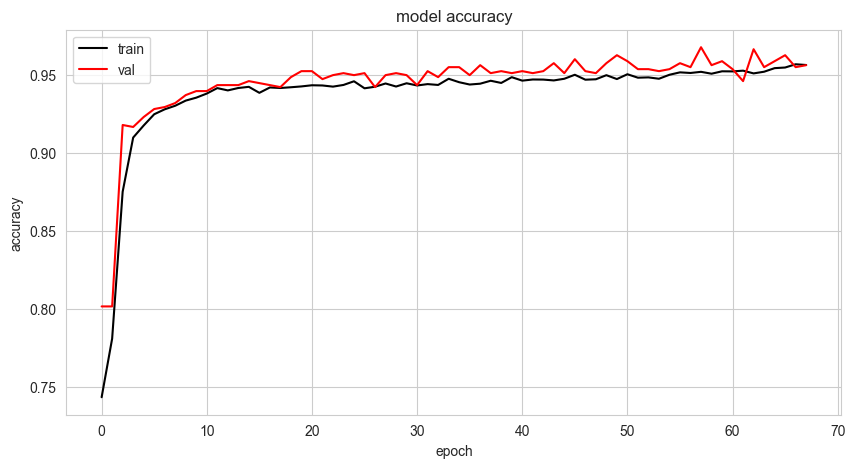

In [137]:
plot_model_accuracy(RNN_fwd_2_history, 10, 5)

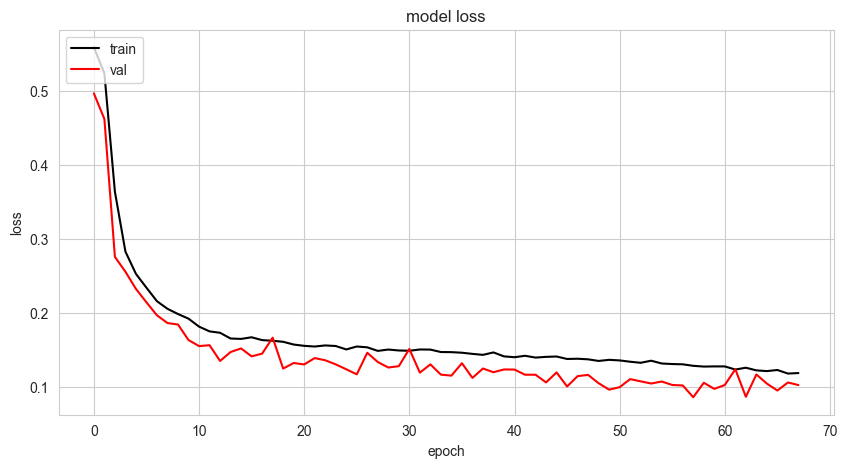

In [138]:
plot_training_curve(RNN_fwd_2_history,10,5)

In [108]:
analyze_model_on_train_set(seq_set_f25, RNN_fwd_2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 994us/step - accuracy: 0.9576 - loss: 0.1026
Train Accurracy: 0.9576482772827148


79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion matrix
- x-axis is true labels.
- y-axis is predicted labels
[[12457    74]
 [  588  2512]]
Train Precision =  0.97138437741686 
 Train Recall =  0.8103225806451613


using /Users/youssefaittizi/Desktop/Benchmark Code/PHM/Data/Models/RNN_fwd_2.h5


3/3 - 0s - 77ms/step - accuracy: 0.9355 - loss: 0.1734
Total time taken for inferencing:  0.25  secs
Test Accurracy: 0.9354838728904724
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Confusion matrix
- x-axis is true labels.
- y-axis is predicted labels
[[66  2]
 [ 4 21]]
Test Precision:  0.9130434782608695 
 Test Recall:  0.84 
 Test F1-score: 0.8749999999999999


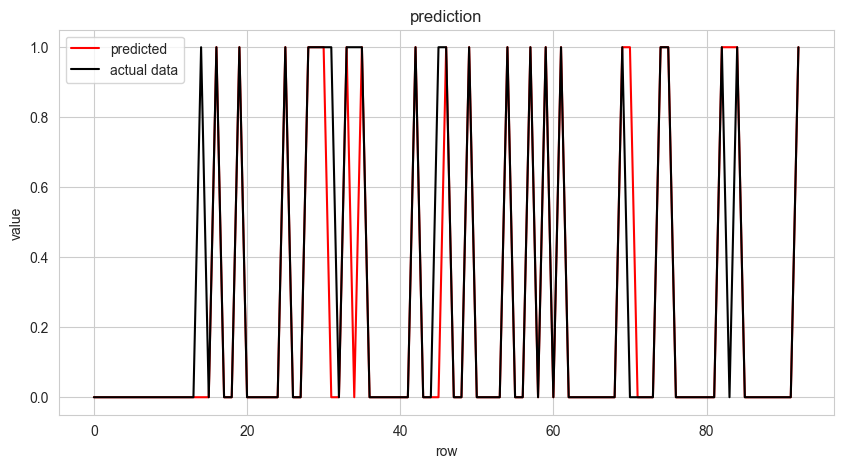

In [139]:
analyze_model_on_test_set(sequence_cols_25, RNN_fwd_2_path, 10, 5)

In [110]:
#Import a bidirectional library.
from tensorflow.keras.layers import Bidirectional

features_dim = seq_set_f25.shape[2] # Number of features (25)
out_dim = label_set.shape[1] # One output for each sequence (failure_within_w1)

print("Features dimension: ", features_dim)
print("Output dimension: ", out_dim)

RNN_bi = Sequential()

# Understanding return_sequences and the connection across RNN layers
# Note that we have to return the sequence from the first layer so the next layer can get the sequence.

RNN_bi.add(Bidirectional( #We need to pass the RNN unit as an argument of the Bidirectional() function.
         SimpleRNN(
         input_shape=(sequence_length, features_dim),
         units=6,
         return_sequences=True)))
RNN_bi.add(Dropout(0.2))

RNN_bi.add(SimpleRNN(
          units=3,
          return_sequences=False))
RNN_bi.add(Dropout(0.2))

RNN_bi.add(Dense(units=out_dim, activation='sigmoid'))

# Compile the model.
RNN_bi.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Define the path to save the model.
RNN_bi_path = '/Users/youssefaittizi/Desktop/Benchmark Code/PHM/Data/Models/RNN_bi.h5'


Features dimension:  25
Output dimension:  1


/Users/youssefaittizi/Desktop/Benchmark Code/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [111]:
import time
epochs = 200
batch_size = 200
start = time.time()

# Fit the network
RNN_bi_history = RNN_bi.fit(seq_set_f25, label_set, epochs=epochs, batch_size=batch_size, validation_split=0.05, verbose=2,
          callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=0, mode='min'),
                       keras.callbacks.ModelCheckpoint(RNN_bi_path,monitor='val_loss', save_best_only=True, mode='min', verbose=0)]
          )
end = time.time()
print("Total time taken for training: ", "{:.2f}".format((end-start)), " secs")

Epoch 1/200


75/75 - 2s - 29ms/step - accuracy: 0.6503 - loss: 0.6753 - val_accuracy: 0.8018 - val_loss: 0.5006
Epoch 2/200


75/75 - 1s - 10ms/step - accuracy: 0.7931 - loss: 0.4791 - val_accuracy: 0.8325 - val_loss: 0.2969
Epoch 3/200


75/75 - 1s - 8ms/step - accuracy: 0.8930 - loss: 0.2764 - val_accuracy: 0.9246 - val_loss: 0.2155
Epoch 4/200


75/75 - 1s - 7ms/step - accuracy: 0.9290 - loss: 0.2157 - val_accuracy: 0.9335 - val_loss: 0.1828
Epoch 5/200


...

75/75 - 1s - 9ms/step - accuracy: 0.9407 - loss: 0.1724 - val_accuracy: 0.9463 - val_loss: 0.1460
Epoch 11/200
75/75 - 1s - 8ms/step - accuracy: 0.9416 - loss: 0.1676 - val_accuracy: 0.9450 - val_loss: 0.1519
Epoch 12/200


75/75 - 1s - 8ms/step - accuracy: 0.9428 - loss: 0.1645 - val_accuracy: 0.9476 - val_loss: 0.1404
Epoch 13/200
75/75 - 1s - 9ms/step - accuracy: 0.9420 - loss: 0.1628 - val_accuracy: 0.9501 - val_loss: 0.1496
Epoch 14/200
75/75 - 1s - 9ms/step - accuracy: 0.9407 - loss: 0.1638 - val_accuracy: 0.9501 - val_loss: 0.1430
Epoch 15/200
75/75 - 1s - 8ms/step - accuracy: 0.9430 - loss: 0.1591 - val_accuracy: 0.9450 - val_loss: 0.1563
Epoch 16/200


75/75 - 1s - 8ms/step - accuracy: 0.9426 - loss: 0.1612 - val_accuracy: 0.9476 - val_loss: 0.1256
Epoch 17/200
75/75 - 1s - 8ms/step - accuracy: 0.9425 - loss: 0.1566 - val_accuracy: 0.9514 - val_loss: 0.1327
Epoch 18/200
75/75 - 1s - 9ms/step - accuracy: 0.9435 - loss: 0.1538 - val_accuracy: 0.9488 - val_loss: 0.1334
Epoch 19/200
75/75 - 1s - 8ms/step - accuracy: 0.9433 - loss: 0.1538 - val_accuracy: 0.9488 - val_loss: 0.1301
Epoch 20/200
75/75 - 1s - 7ms/step - accuracy: 0.9438 - loss: 0.1530 - val_accuracy: 0.9476 - val_loss: 0.1452
Epoch 21/200


75/75 - 1s - 7ms/step - accuracy: 0.9430 - loss: 0.1536 - val_accuracy: 0.9501 - val_loss: 0.1201
Epoch 22/200
75/75 - 1s - 7ms/step - accuracy: 0.9453 - loss: 0.1499 - val_accuracy: 0.9527 - val_loss: 0.1228
Epoch 23/200
75/75 - 1s - 7ms/step - accuracy: 0.9461 - loss: 0.1470 - val_accuracy: 0.9540 - val_loss: 0.1211
Epoch 24/200
75/75 - 1s - 7ms/step - accuracy: 0.9431 - loss: 0.1517 - val_accuracy: 0.9527 - val_loss: 0.1224
Epoch 25/200
75/75 - 1s - 7ms/step - accuracy: 0.9455 - loss: 0.1484 - val_accuracy: 0.9501 - val_loss: 0.1486
Epoch 26/200
75/75 - 1s - 7ms/step - accuracy: 0.9455 - loss: 0.1485 - val_accuracy: 0.9501 - val_loss: 0.1346
Epoch 27/200
75/75 - 1s - 7ms/step - accuracy: 0.9453 - loss: 0.1484 - val_accuracy: 0.9501 - val_loss: 0.1434
Epoch 28/200
75/75 - 1s - 7ms/step - accuracy: 0.9465 - loss: 0.1446 - val_accuracy: 0.9514 - val_loss: 0.1411
Epoch 29/200
75/75 - 1s - 7ms/step - accuracy: 0.9476 - loss: 0.1474 - val_accuracy: 0.9527 - val_loss: 0.1351
Epoch 30/200


75/75 - 1s - 7ms/step - accuracy: 0.9458 - loss: 0.1478 - val_accuracy: 0.9514 - val_loss: 0.1092
Epoch 31/200
75/75 - 1s - 7ms/step - accuracy: 0.9471 - loss: 0.1429 - val_accuracy: 0.9552 - val_loss: 0.1180
Epoch 32/200
75/75 - 1s - 7ms/step - accuracy: 0.9440 - loss: 0.1479 - val_accuracy: 0.9578 - val_loss: 0.1151
Epoch 33/200
75/75 - 1s - 7ms/step - accuracy: 0.9473 - loss: 0.1426 - val_accuracy: 0.9514 - val_loss: 0.1139
Epoch 34/200
75/75 - 1s - 7ms/step - accuracy: 0.9487 - loss: 0.1389 - val_accuracy: 0.9527 - val_loss: 0.1273
Epoch 35/200
75/75 - 1s - 7ms/step - accuracy: 0.9476 - loss: 0.1405 - val_accuracy: 0.9476 - val_loss: 0.1118
Epoch 36/200
75/75 - 1s - 7ms/step - accuracy: 0.9488 - loss: 0.1379 - val_accuracy: 0.9527 - val_loss: 0.1181
Epoch 37/200
75/75 - 1s - 7ms/step - accuracy: 0.9490 - loss: 0.1372 - val_accuracy: 0.9527 - val_loss: 0.1127
Epoch 38/200
75/75 - 1s - 7ms/step - accuracy: 0.9464 - loss: 0.1416 - val_accuracy: 0.9527 - val_loss: 0.1274
Epoch 39/200
7

In [112]:
print(RNN_bi.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 50, 12)         │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ (None, 3)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,310 (5.12 KB)

 Trainable params: 436 (1.70 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 874 (3.42 KB)

None


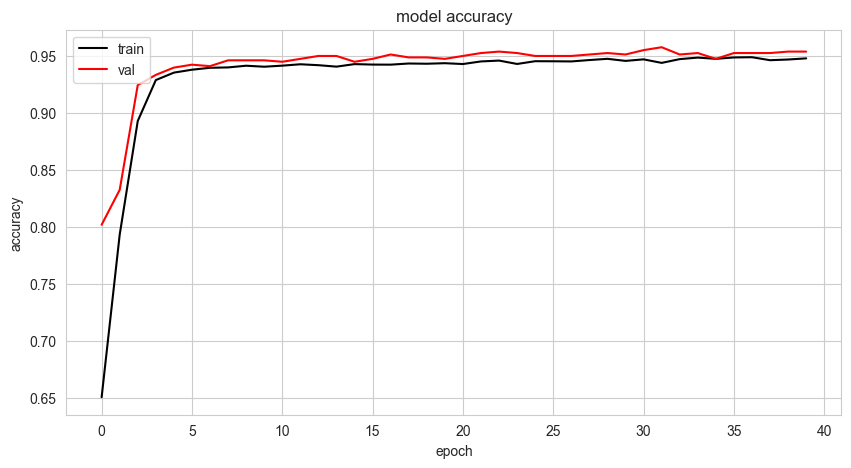

In [140]:
plot_model_accuracy(RNN_bi_history,10,5)

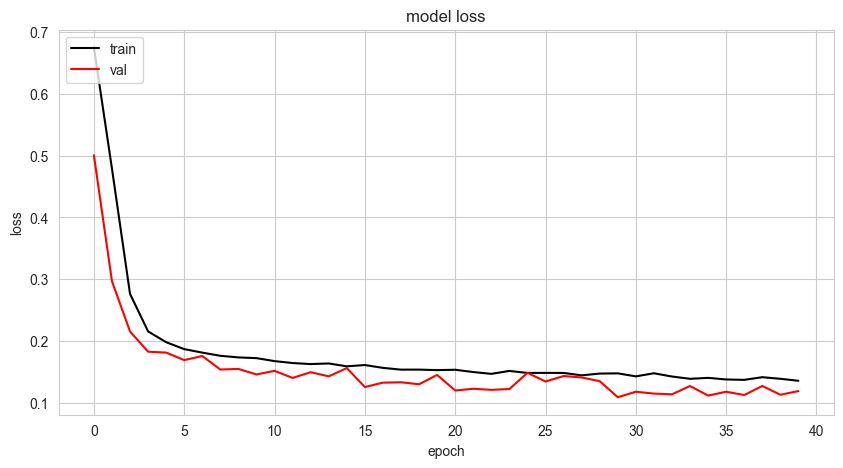

In [141]:
plot_training_curve(RNN_bi_history,10,5)

In [115]:
analyze_model_on_train_set(seq_set_f25, RNN_bi)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9575 - loss: 0.1127
Train Accurracy: 0.9574563503265381
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Confusion matrix
- x-axis is true labels.
- y-axis is predicted labels
[[12311   220]
 [  445  2655]]
Train Precision =  0.9234782608695652 
 Train Recall =  0.8564516129032258


using /Users/youssefaittizi/Desktop/Benchmark Code/PHM/Data/Models/RNN_bi.h5


3/3 - 1s - 199ms/step - accuracy: 0.9247 - loss: 0.1820
Total time taken for inferencing:  0.61  secs
Test Accurracy: 0.9247311949729919
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Confusion matrix
- x-axis is true labels.
- y-axis is predicted labels
[[66  2]
 [ 5 20]]
Test Precision:  0.9090909090909091 
 Test Recall:  0.8 
 Test F1-score: 0.8510638297872342


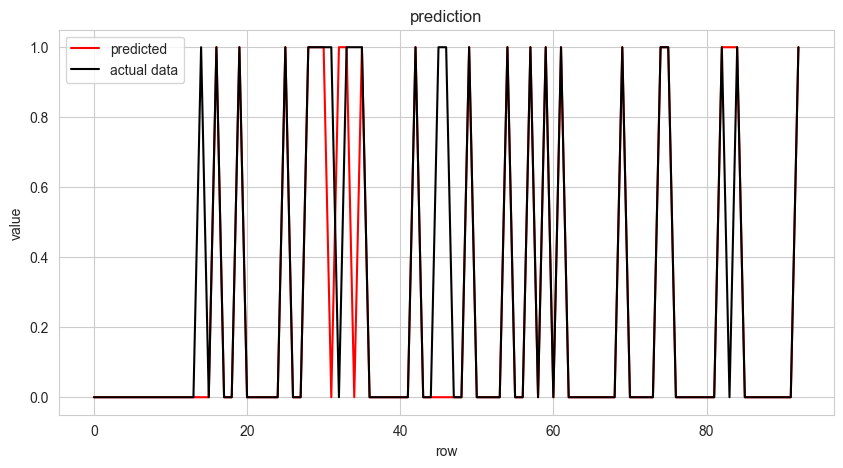

In [142]:
analyze_model_on_test_set(sequence_cols_25, RNN_bi_path,10,5)


In [117]:
# Model - (100 LSTM units with 0.2 dropout) + 
#         (50 LSTM units with 0.2 dropout) + 
#         (dense layer with sigmoid activation)

features_dim = seq_set_f25.shape[2] # number of features
out_dim = label_set.shape[1] # 1 Label (Target variable is failure_within_w1)

print("Features dimension: ", features_dim)
print("Output dimension: ", out_dim)

model = Sequential()

# Understanding of return_sequences and connection across LSTM layers
model.add(LSTM(
         input_shape=(sequence_length, features_dim),
         units=100,
         return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(
          units=50,
          return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(units=out_dim, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model.summary())

# Define path to save model
model_path = '/Users/youssefaittizi/Desktop/Benchmark Code/PHM/Data/Models/LSTM_fwd.h5'

Features dimension:  25
Output dimension:  1


/Users/youssefaittizi/Desktop/Benchmark Code/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 100)        │        50,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,651 (315.04 KB)

 Trainable params: 80,651 (315.04 KB)

 Non-trainable params: 0 (0.00 B)

None


In [118]:
import time
epochs = 200
batch_size = 200
start = time.time()

# Fit the network
history = model.fit(seq_set_f25, label_set, epochs=epochs, batch_size=batch_size, validation_split=0.05, verbose=2,
          callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=0, mode='min'),
                       keras.callbacks.ModelCheckpoint(model_path,monitor='val_loss', save_best_only=True, mode='min', verbose=0)]
          )
end = time.time()
print("Total time taken for training: ", "{:.2f}".format((end-start)), " secs")

Epoch 1/200


75/75 - 6s - 73ms/step - accuracy: 0.8902 - loss: 0.2538 - val_accuracy: 0.8887 - val_loss: 0.2637
Epoch 2/200


75/75 - 4s - 60ms/step - accuracy: 0.9586 - loss: 0.1082 - val_accuracy: 0.9744 - val_loss: 0.0693
Epoch 3/200


75/75 - 5s - 61ms/step - accuracy: 0.9648 - loss: 0.0842 - val_accuracy: 0.9872 - val_loss: 0.0445
Epoch 4/200


75/75 - 4s - 60ms/step - accuracy: 0.9710 - loss: 0.0679 - val_accuracy: 0.9808 - val_loss: 0.0366
Epoch 5/200


75/75 - 5s - 60ms/step - accuracy: 0.9733 - loss: 0.0638 - val_accuracy: 0.9847 - val_loss: 0.0363
Epoch 6/200
75/75 - 5s - 68ms/step - accuracy: 0.9745 - loss: 0.0617 - val_accuracy: 0.9783 - val_loss: 0.0420
Epoch 7/200
75/75 - 5s - 68ms/step - accuracy: 0.9732 - loss: 0.0635 - val_accuracy: 0.9847 - val_loss: 0.0366
Epoch 8/200


75/75 - 5s - 62ms/step - accuracy: 0.9753 - loss: 0.0603 - val_accuracy: 0.9898 - val_loss: 0.0261
Epoch 9/200
75/75 - 5s - 63ms/step - accuracy: 0.9743 - loss: 0.0596 - val_accuracy: 0.9808 - val_loss: 0.0476
Epoch 10/200
75/75 - 5s - 63ms/step - accuracy: 0.9772 - loss: 0.0551 - val_accuracy: 0.9783 - val_loss: 0.0438
Epoch 11/200
75/75 - 4s - 60ms/step - accuracy: 0.9760 - loss: 0.0535 - val_accuracy: 0.9859 - val_loss: 0.0330
Epoch 12/200
75/75 - 5s - 68ms/step - accuracy: 0.9770 - loss: 0.0541 - val_accuracy: 0.9872 - val_loss: 0.0310
Epoch 13/200
75/75 - 5s - 66ms/step - accuracy: 0.9776 - loss: 0.0543 - val_accuracy: 0.9783 - val_loss: 0.0419
Epoch 14/200
75/75 - 5s - 66ms/step - accuracy: 0.9772 - loss: 0.0541 - val_accuracy: 0.9783 - val_loss: 0.0406
Epoch 15/200
75/75 - 5s - 67ms/step - accuracy: 0.9730 - loss: 0.0644 - val_accuracy: 0.9757 - val_loss: 0.0488
Epoch 16/200
75/75 - 5s - 62ms/step - accuracy: 0.9801 - loss: 0.0487 - val_accuracy: 0.9795 - val_loss: 0.0379
Epoch 

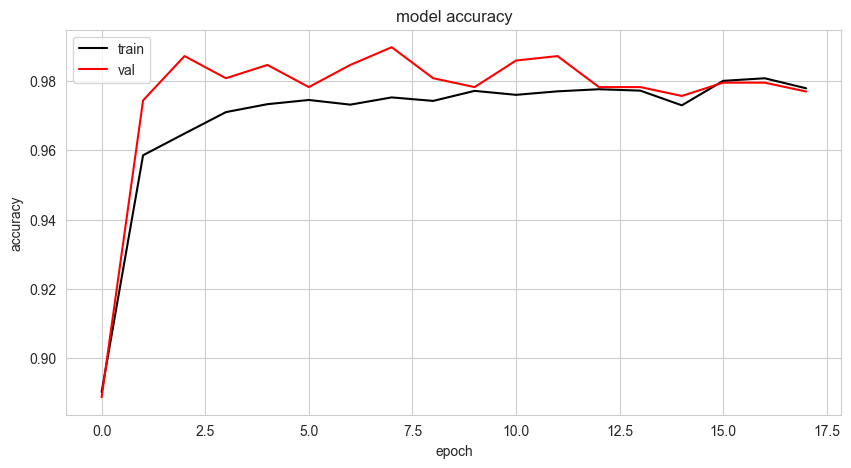

In [174]:
# Plotting the change in model accuracy on train and val sets
fig_acc = plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], color=colors[0])
plt.plot(history.history['val_accuracy'], color=colors[1])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

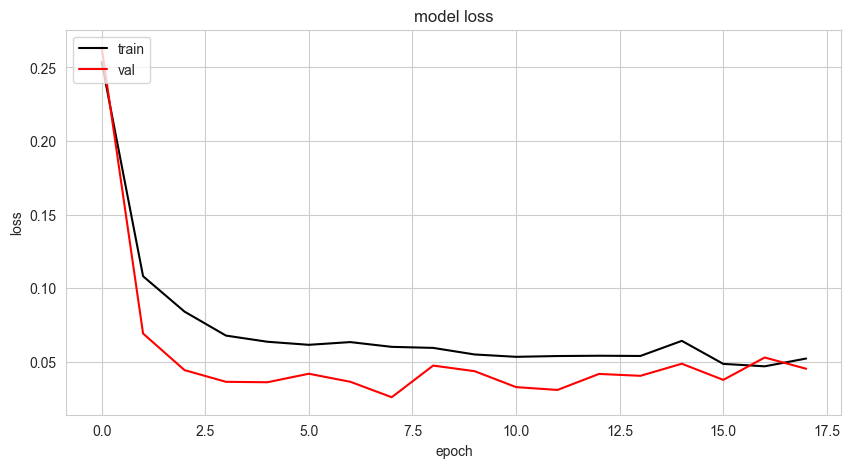

In [175]:
# Plot model loss for train and test sets
fig_acc = plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], color=colors[0])
plt.plot(history.history['val_loss'], color=colors[1])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [121]:
# Training metrics
scores = model.evaluate(seq_set_f25, label_set, verbose=1, batch_size=50)
print('Train Accurracy: {}'.format(scores[1]))

# Make predictions and compute confusion matrix
y_pred = (model.predict(seq_set_f25, verbose=1, batch_size=200) > 0.5).astype("int32")
y_true = label_set

test_set = pd.DataFrame(y_pred)
test_set.to_csv('binary_submit_train.csv', index = None)

print('Confusion matrix\n- x-axis is true labels.\n- y-axis is predicted labels')
cm = confusion_matrix(y_true, y_pred)
print(cm)

# Compute precision and recall
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
print( 'Train Precision = ', precision, '\n', 'Train Recall = ', recall)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9823 - loss: 0.0443
Train Accurracy: 0.9822788238525391
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
Confusion matrix
- x-axis is true labels.
- y-axis is predicted labels
[[12488    43]
 [  234  2866]]
Train Precision =  0.9852182880715022 
 Train Recall =  0.9245161290322581


3/3 - 0s - 100ms/step - accuracy: 0.9570 - loss: 0.0601
Total time taken for inferencing:  0.33  secs
Test Accurracy: 0.9569892287254333
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Confusion matrix
- x-axis is true labels.
- y-axis is predicted labels
[[66  2]
 [ 2 23]]
Test Precision:  0.92 
 Test Recall:  0.92 
 Test F1-score: 0.92


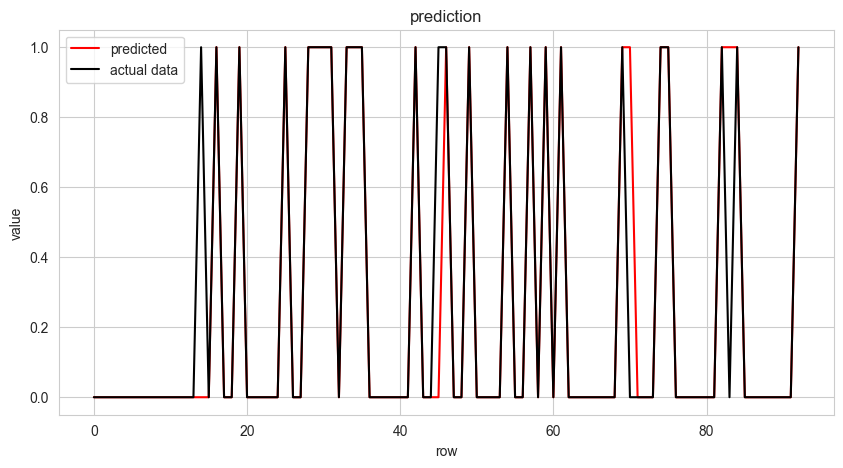

In [146]:
# Considering all the last sequences of test set
last_test_seq = [test_df[test_df['id']==id][sequence_cols_25].values[-sequence_length:] 
                       for id in test_df['id'].unique() if len(test_df[test_df['id']==id]) >= sequence_length]
last_test_seq = np.asarray(last_test_seq).astype(np.float32)

# Get labels of test set
y_mask = [len(test_df[test_df['id']==id]) >= sequence_length for id in test_df['id'].unique()]
last_test_label = test_df.groupby('id')['failure_within_w1'].nth(-1)[y_mask].values
last_test_label = last_test_label.reshape(last_test_label.shape[0],1).astype(np.float32)

# If best model weights were saved then load it
if os.path.isfile(model_path):
    estimator = load_model(model_path)

# Test metrics
start = time.time()
scores_test = estimator.evaluate(last_test_seq, last_test_label, verbose=2)
end = time.time()
print("Total time taken for inferencing: ", "{:.2f}".format((end-start)), " secs")

print('Test Accurracy: {}'.format(scores_test[1]))

# Make predictions and compute confusion matrix
y_pred_test = (estimator.predict(last_test_seq) > 0.5).astype("int32")
y_true_test = last_test_label

test_set = pd.DataFrame(y_pred_test)
test_set.to_csv('binary_submit_test.csv', index = None)

print('Confusion matrix\n- x-axis is true labels.\n- y-axis is predicted labels')
conf_m = confusion_matrix(y_true_test, y_pred_test)
print(conf_m)

# Compute precision and recall
precision_test = precision_score(y_true_test, y_pred_test)
recall_test = recall_score(y_true_test, y_pred_test)
f1_test = 2 * (precision_test * recall_test) / (precision_test + recall_test)
print( 'Test Precision: ', precision_test, '\n', 'Test Recall: ', recall_test,'\n', 'Test F1-score:', f1_test )

# Plot in blue color the predicted data and in green color the
# Actual data to verify visually the accuracy of the model.
fig_verify = plt.figure(figsize=(10, 5))
plt.plot(y_pred_test, color=colors[1])
plt.plot(y_true_test, color=colors[0])
plt.title('prediction')
plt.ylabel('value')
plt.xlabel('row')
plt.legend(['predicted', 'actual data'], loc='upper left')
plt.show()
